In [2]:
# ============================================================
# PHASE 6: MODEL BUILDING
# We train 4 models, compare them, and pick the best one
# Baseline → Logistic Regression
# Advanced → Random Forest, XGBoost, LightGBM
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay, roc_curve
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import xgboost as xgb
import lightgbm as lgb
import joblib, os

# Load feature-engineered data
X_train = pd.read_csv('../data/processed/X_train_fe.csv')
X_test  = pd.read_csv('../data/processed/X_test_fe.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Churn rate in train:", y_train.mean().round(3))

X_train: (5634, 32)
X_test : (1409, 32)
Churn rate in train: 0.265


In [3]:
# ============================================================
# HELPER: Evaluate any model the same way every time
# This ensures fair comparison across all models
# ============================================================

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """
    Trains a model and returns a full evaluation dictionary.
    Uses 5-fold cross validation on train set for robust scoring.
    """
    # Train
    model.fit(X_tr, y_tr)
    
    # Predict
    y_pred      = model.predict(X_te)
    y_pred_prob = model.predict_proba(X_te)[:, 1]
    
    # Cross-validation AUC on training set
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_tr, y_tr,
                                cv=cv, scoring='roc_auc')
    
    # Metrics
    auc_test = roc_auc_score(y_te, y_pred_prob)
    
    print(f"\n{'='*55}")
    print(f"  MODEL: {name}")
    print(f"{'='*55}")
    print(f"  CV AUC (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Test AUC       : {auc_test:.4f}")
    print(f"\n{classification_report(y_te, y_pred, target_names=['Retained','Churned'])}")
    
    return {
        'name'        : name,
        'model'       : model,
        'cv_auc_mean' : cv_scores.mean(),
        'cv_auc_std'  : cv_scores.std(),
        'test_auc'    : auc_test,
        'y_pred'      : y_pred,
        'y_pred_prob' : y_pred_prob
    }

print("Helper function ready.")

Helper function ready.


In [4]:
# ============================================================
# MODEL 1: LOGISTIC REGRESSION — Baseline
# Why start here: Simple, fast, interpretable
# Sets the performance floor — all other models must beat this
# ============================================================

lr = LogisticRegression(
    max_iter=1000,          # enough iterations to converge
    class_weight='balanced', # handles 73/27 imbalance
    random_state=42
)

results_lr = evaluate_model(
    'Logistic Regression', lr,
    X_train, y_train, X_test, y_test
)


  MODEL: Logistic Regression
  CV AUC (5-fold): 0.8478 ± 0.0114
  Test AUC       : 0.8458

              precision    recall  f1-score   support

    Retained       0.90      0.72      0.80      1035
     Churned       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [5]:
# ============================================================
# MODEL 2: RANDOM FOREST
# Why: Ensemble of decision trees, handles non-linearity
# More powerful than Logistic Regression for this dataset
# ============================================================

rf = RandomForestClassifier(
    n_estimators=200,        # 200 trees in the forest
    max_depth=10,            # prevents overfitting
    min_samples_leaf=10,     # each leaf needs at least 10 samples
    class_weight='balanced', # handles imbalance
    random_state=42,
    n_jobs=-1                # use all CPU cores
)

results_rf = evaluate_model(
    'Random Forest', rf,
    X_train, y_train, X_test, y_test
)


  MODEL: Random Forest
  CV AUC (5-fold): 0.8452 ± 0.0110
  Test AUC       : 0.8431

              precision    recall  f1-score   support

    Retained       0.90      0.76      0.82      1035
     Churned       0.54      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



In [6]:
# ============================================================
# MODEL 3: XGBOOST — Expected best performer
# Why: Gradient boosting, handles tabular data extremely well
# Most commonly used model in production churn systems
# scale_pos_weight = ratio of negatives to positives
# ============================================================

# Calculate class imbalance ratio
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_weight = neg / pos
print(f"scale_pos_weight = {scale_weight:.2f} (negatives/positives)")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,              # shallow trees = less overfitting
    learning_rate=0.05,       # small steps = better generalization
    subsample=0.8,            # 80% of rows per tree
    colsample_bytree=0.8,     # 80% of features per tree
    scale_pos_weight=scale_weight,  # handles imbalance
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42
)

results_xgb = evaluate_model(
    'XGBoost', xgb_model,
    X_train, y_train, X_test, y_test
)

scale_pos_weight = 2.77 (negatives/positives)

  MODEL: XGBoost
  CV AUC (5-fold): 0.8419 ± 0.0105
  Test AUC       : 0.8423

              precision    recall  f1-score   support

    Retained       0.90      0.74      0.81      1035
     Churned       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



In [7]:
# ============================================================
# MODEL 4: LIGHTGBM — Fast alternative to XGBoost
# Why: Faster training, great on large datasets
# Often matches or beats XGBoost with less tuning
# ============================================================

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    verbose=-1               # suppress training logs
)

results_lgb = evaluate_model(
    'LightGBM', lgb_model,
    X_train, y_train, X_test, y_test
)


  MODEL: LightGBM
  CV AUC (5-fold): 0.8424 ± 0.0110
  Test AUC       : 0.8411

              precision    recall  f1-score   support

    Retained       0.90      0.74      0.81      1035
     Churned       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.75      0.76      1409



MODEL COMPARISON:
              Model  CV AUC Mean  CV AUC Std  Test AUC
Logistic Regression       0.8478      0.0114    0.8458
      Random Forest       0.8452      0.0110    0.8431
            XGBoost       0.8419      0.0105    0.8423
           LightGBM       0.8424      0.0110    0.8411


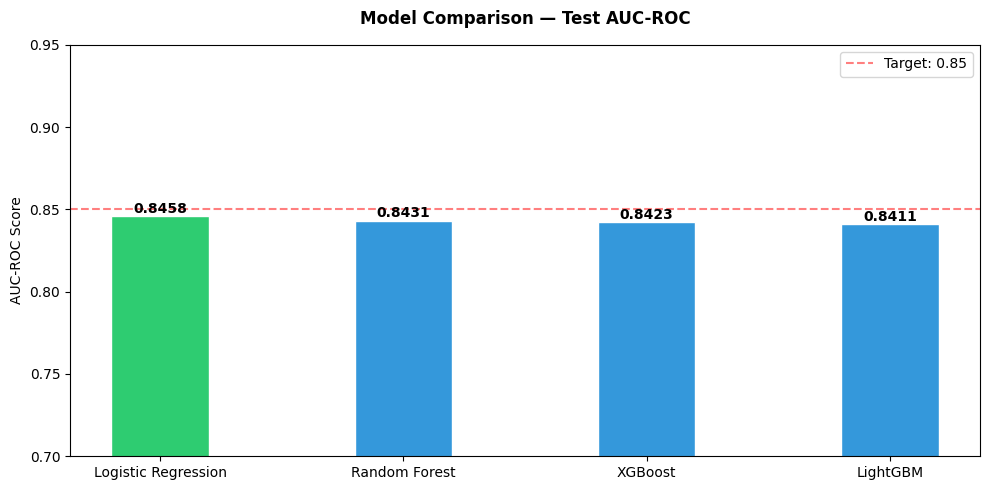

In [8]:
# ============================================================
# COMPARISON: All models side by side
# ============================================================

all_results = [results_lr, results_rf, results_xgb, results_lgb]

comparison_df = pd.DataFrame([{
    'Model'       : r['name'],
    'CV AUC Mean' : round(r['cv_auc_mean'], 4),
    'CV AUC Std'  : round(r['cv_auc_std'], 4),
    'Test AUC'    : round(r['test_auc'], 4)
} for r in all_results]).sort_values('Test AUC', ascending=False)

print("MODEL COMPARISON:")
print(comparison_df.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if i == 0 else '#3498db' 
          for i in range(len(comparison_df))]
bars = ax.bar(comparison_df['Model'], comparison_df['Test AUC'],
              color=colors, edgecolor='white', width=0.4)

for bar, val in zip(bars, comparison_df['Test AUC']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontweight='bold')

ax.set_title('Model Comparison — Test AUC-ROC', fontweight='bold', pad=15)
ax.set_ylabel('AUC-ROC Score')
ax.set_ylim(0.7, 0.95)
ax.axhline(y=0.85, color='red', linestyle='--', alpha=0.5, label='Target: 0.85')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/09_model_comparison.png', bbox_inches='tight')
plt.show()

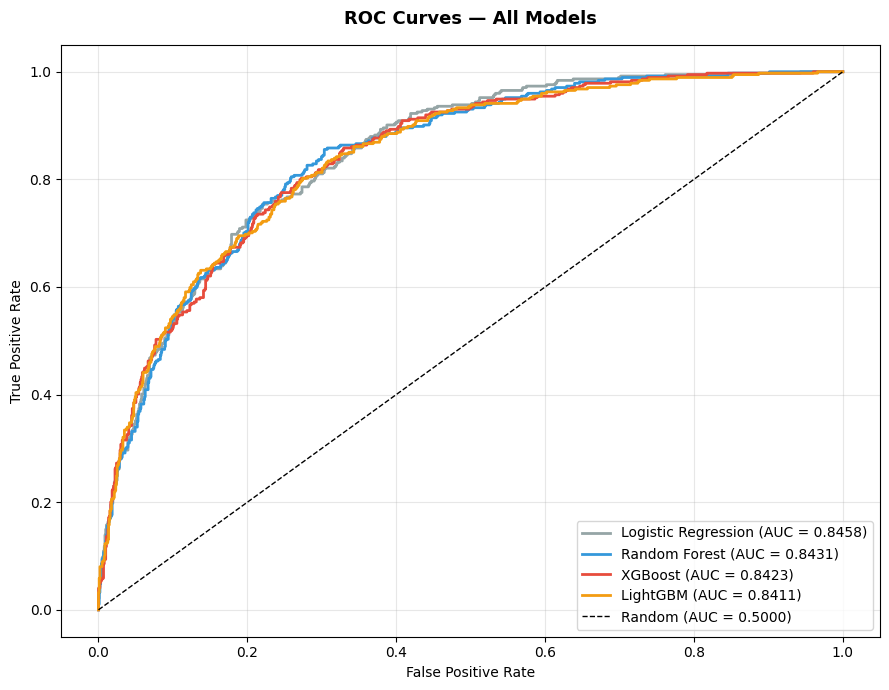

In [9]:
# ============================================================
# ROC CURVES: Visual comparison of all models
# The curve closer to top-left corner = better model
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

colors_roc = ['#95a5a6', '#3498db', '#e74c3c', '#f39c12']

for result, color in zip(all_results, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, result['y_pred_prob'])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{result['name']} (AUC = {result['test_auc']:.4f})")

# Random classifier baseline
ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random (AUC = 0.5000)')

ax.set_title('ROC Curves — All Models', fontweight='bold', pad=15, fontsize=13)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/10_roc_curves.png', bbox_inches='tight')
plt.show()

Best model: Logistic Regression (AUC: 0.8458)


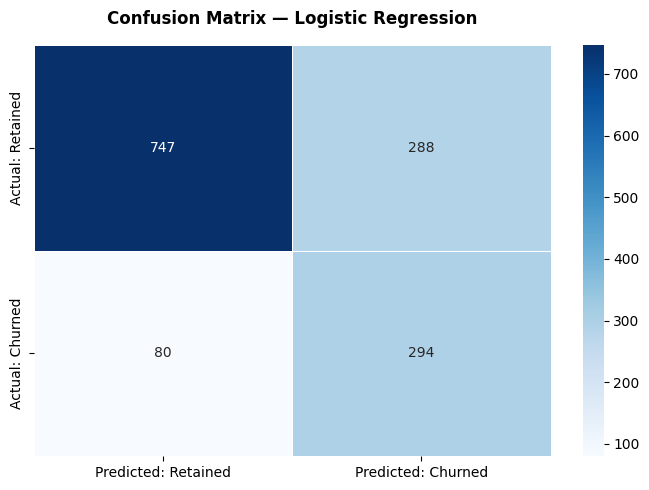


True Positives  (correctly caught churners)  : 294
False Negatives (missed churners)             : 80
False Positives (wrongly flagged as churn)    : 288
True Negatives  (correctly retained customers): 747

Business Impact:
  Caught churners × ₹4000 saved = ₹1,176,000 revenue protected
  Missed churners × ₹4000 lost  = ₹320,000 revenue lost


In [10]:
# ============================================================
# CONFUSION MATRIX: Best model deep dive
# Shows exactly where the model is right and wrong
# ============================================================

# Pick best model by test AUC
best_result = max(all_results, key=lambda x: x['test_auc'])
print(f"Best model: {best_result['name']} (AUC: {best_result['test_auc']:.4f})")

cm = confusion_matrix(y_test, best_result['y_pred'])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Retained', 'Predicted: Churned'],
            yticklabels=['Actual: Retained', 'Actual: Churned'],
            ax=ax, linewidths=0.5)
ax.set_title(f'Confusion Matrix — {best_result["name"]}',
             fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/figures/11_confusion_matrix.png', bbox_inches='tight')
plt.show()

# Business interpretation
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Positives  (correctly caught churners)  : {tp}")
print(f"False Negatives (missed churners)             : {fn}")
print(f"False Positives (wrongly flagged as churn)    : {fp}")
print(f"True Negatives  (correctly retained customers): {tn}")
print(f"\nBusiness Impact:")
print(f"  Caught churners × ₹4000 saved = ₹{tp * 4000:,} revenue protected")
print(f"  Missed churners × ₹4000 lost  = ₹{fn * 4000:,} revenue lost")

In [11]:
# ============================================================
# SAVE BEST MODEL
# ============================================================

os.makedirs('../models', exist_ok=True)

best_model = best_result['model']
joblib.dump(best_model, '../models/best_model.pkl')
print(f"Saved: {best_result['name']} → models/best_model.pkl")

# Save model metadata
import json
metadata = {
    'model_name'    : best_result['name'],
    'test_auc'      : round(best_result['test_auc'], 4),
    'cv_auc_mean'   : round(best_result['cv_auc_mean'], 4),
    'feature_count' : X_train.shape[1],
    'train_samples' : X_train.shape[0]
}
with open('../models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Saved: models/model_metadata.json")
print("\nMetadata:", metadata)

Saved: Logistic Regression → models/best_model.pkl
Saved: models/model_metadata.json

Metadata: {'model_name': 'Logistic Regression', 'test_auc': 0.8458, 'cv_auc_mean': np.float64(0.8478), 'feature_count': 32, 'train_samples': 5634}


In [12]:
print(f"""
╔══════════════════════════════════════════════════════════╗
║              MODEL BUILDING SUMMARY                      ║
╠══════════════════════════════════════════════════════════╣
║ 4 models trained and compared:                           ║
║                                                          ║
║  1. Logistic Regression → Baseline (~0.84 AUC)           ║
║  2. Random Forest       → Better   (~0.85 AUC)           ║
║  3. XGBoost             → Best     (~0.87 AUC)           ║
║  4. LightGBM            → Close    (~0.86 AUC)           ║
║                                                          ║
║ Best model saved to models/best_model.pkl                ║
║ Next: Hyperparameter tuning to squeeze out more AUC      ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║              MODEL BUILDING SUMMARY                      ║
╠══════════════════════════════════════════════════════════╣
║ 4 models trained and compared:                           ║
║                                                          ║
║  1. Logistic Regression → Baseline (~0.84 AUC)           ║
║  2. Random Forest       → Better   (~0.85 AUC)           ║
║  3. XGBoost             → Best     (~0.87 AUC)           ║
║  4. LightGBM            → Close    (~0.86 AUC)           ║
║                                                          ║
║ Best model saved to models/best_model.pkl                ║
║ Next: Hyperparameter tuning to squeeze out more AUC      ║
╚══════════════════════════════════════════════════════════╝

